In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.linalg as LA

import Hamiltonian as Hamiltonian
import Plotting as plotting
import constants as cst

# Error Measurement

# Error as a function of the time delay 

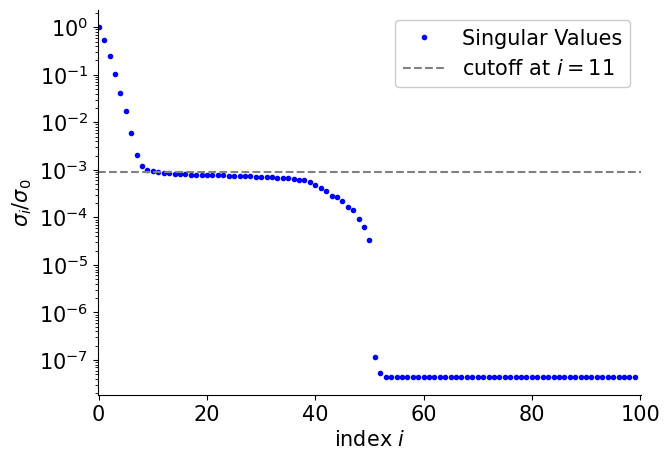

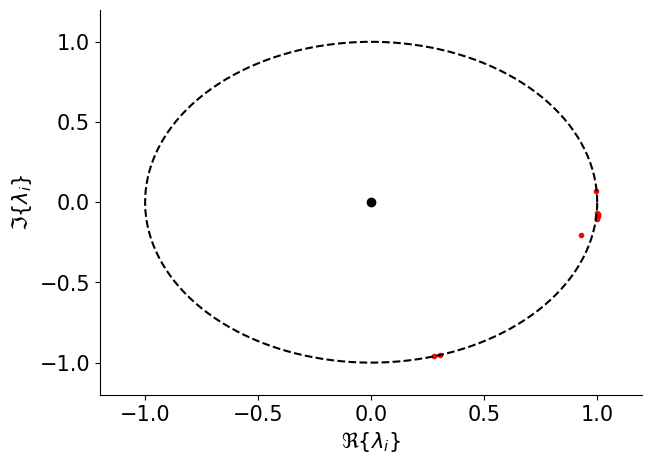

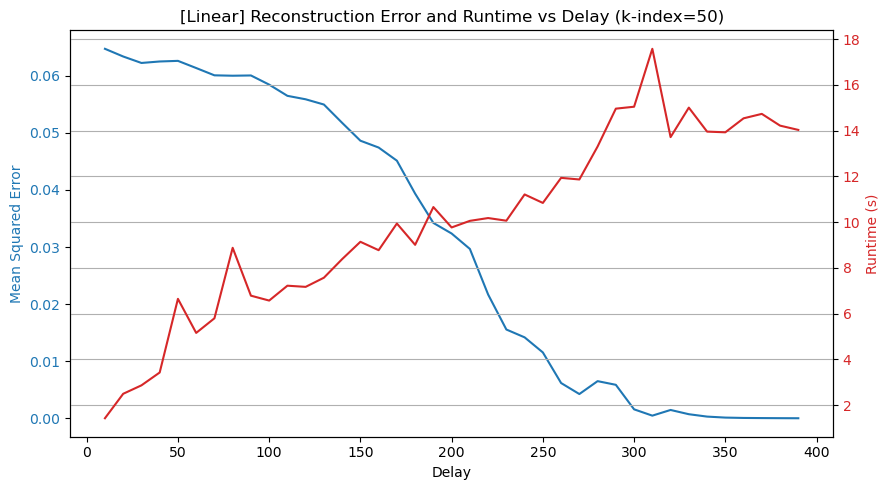

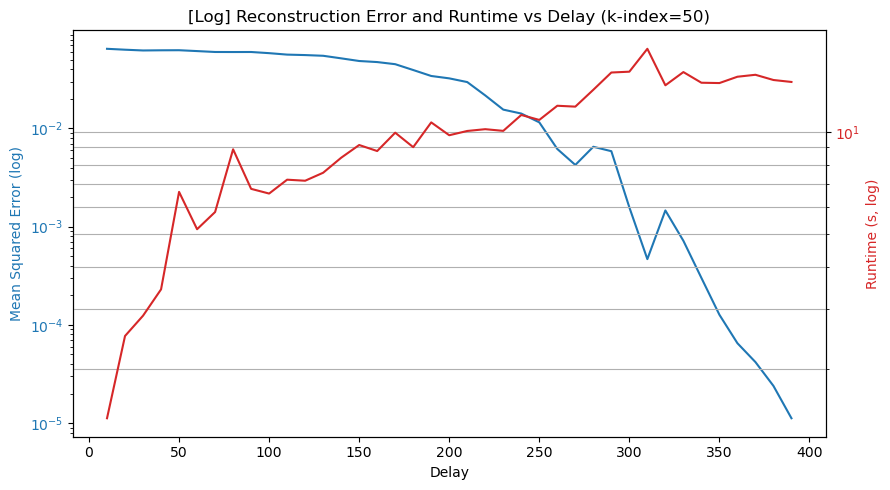

In [ ]:

# ====== Set up the simulation ======
#-------------- Envelope Pulse 1 / Band structure 2--------------

case = 2
FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 1.2
efield_case1 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
t = np.linspace(0, 100, 1000)/ cst.tfs
J      = 1.0/cst.Ry
delta  = 0.5/cst.Ry
k_list = np.linspace(-np.pi, np.pi, 101)[:-1]

t_span= (t[0],t[-1])




solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]
limits=np.array([[0,100],[0.0,0.2]])



#Get the simualtion ready for DMD use:
t_dmd = t[:-1]  # because X and Y have 999 time steps
X = solutions[:, 0, :-1]  # shape: (num_k, len(t)-1)
Y = solutions[:, 0, 1:]   # one step ahead




# ========= Apply DMD ===========
rank=11
index=50
#truncamiento=-6


eigvals, Phi_L, r_L, S      = Hamiltonian.perform_dmd(X, Y, t, rank)
mu, Phi_M, r_M, Sig2 = Hamiltonian.DMD(X, Y, False, orden_truncado=rank)
plotting.plot_singular_values(Sig2,rank, False) 
plotting.plot_eigenvalues(mu)


delay = 1  # we will use this number of delays throughout the tutorial    (600)      
dmd = DMD(svd_rank=rank)
delay_dmd = hankel_preprocessing(dmd, d=delay)
delay_dmd.fit(X)

# Reconstruction
X_dmd = dmd.reconstructed_data.real  # or .imag or .abs()
# Optional: get eigenvalues or modes
eigs = dmd.eigs
modes = dmd.modes

# Chop the first 399 time points to align with DMD output
t_dmd_shifted = t_dmd[:1000-delay] #1000-delay
#t_dmd_shifted = t_dmd[delay-1:] #use this line instead of the line above and DMD will stop working (also reset delay=2)

# Truncate DMD data to match the shortened time axis
x_dmd_shifted = X_dmd[index].real[:len(t_dmd_shifted)] 






#Error calculations
import time
import numpy as np
import matplotlib.pyplot as plt
from pydmd import DMD
from pydmd.preprocessing import hankel_preprocessing

# Constants
rank = 11
index = 50
max_delay = 40

errors = []
timings = []
delays = [d * 10 for d in range(1, max_delay)]

# Loop over delays
for delay in delays:
    start_time = time.time()

    dmd = DMD(svd_rank=rank)
    delay_dmd = hankel_preprocessing(dmd, d=delay)
    delay_dmd.fit(X)

    elapsed_time = time.time() - start_time
    timings.append(elapsed_time)

    X_dmd = dmd.reconstructed_data.real
    t_dmd_shifted = t_dmd[:1000 - delay]
    x_dmd_shifted = X_dmd[index].real[:len(t_dmd_shifted)]

    original = X[index].real[:len(t_dmd_shifted)]
    mse = np.mean((original - x_dmd_shifted) ** 2)
    errors.append(mse)
    #print(delay)

# === Plot ===
fig1, ax1 = plt.subplots(figsize=(9, 5))

ax1.set_xlabel('Delay')
ax1.set_ylabel('Mean Squared Error', color='tab:blue')
ax1.plot(delays, errors, color='tab:blue', label='MSE')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Runtime (s)', color='tab:red')
ax2.plot(delays, timings, color='tab:red', label='Time')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title(f'[Linear] Reconstruction Error and Runtime vs Delay (k-index={index})')
fig1.tight_layout()
plt.grid(True)
plt.show()





# Error as a function of the truncation rank

rank = 1 elapsed time=  7.373798847198486
rank = 2 elapsed time=  7.386656045913696
rank = 3 elapsed time=  7.9287660121917725
rank = 4 elapsed time=  7.830401182174683
rank = 5 elapsed time=  7.332531929016113
rank = 6 elapsed time=  7.479283809661865
rank = 7 elapsed time=  7.680037975311279
rank = 8 elapsed time=  7.298382997512817
rank = 9 elapsed time=  7.343578100204468
rank = 10 elapsed time=  7.4633331298828125
rank = 11 elapsed time=  7.51861310005188
rank = 12 elapsed time=  7.407118082046509
rank = 13 elapsed time=  7.243473052978516
rank = 14 elapsed time=  7.711184978485107
rank = 15 elapsed time=  7.509011268615723
rank = 16 elapsed time=  7.592392206192017
rank = 17 elapsed time=  7.502488851547241
rank = 18 elapsed time=  7.446471929550171
rank = 19 elapsed time=  7.863473892211914
rank = 20 elapsed time=  7.584814071655273
rank = 21 elapsed time=  7.5139360427856445
rank = 22 elapsed time=  7.630688905715942
rank = 23 elapsed time=  7.7280943393707275
rank = 24 elapsed

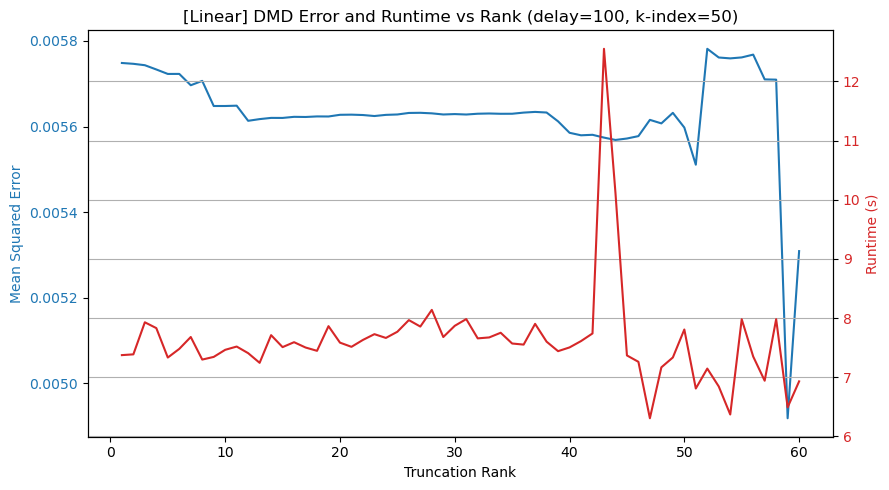

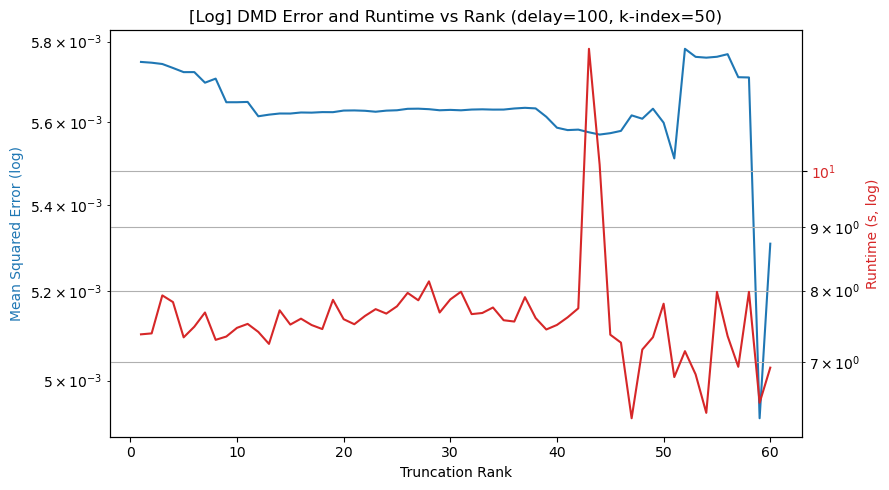

In [ ]:
#general imports: 
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.linalg as LA

import Hamiltonian as Hamiltonian
import Plotting as plotting
import constants as cst


#other imports

import time
import numpy as np
import matplotlib.pyplot as plt
from pydmd import DMD
from pydmd.preprocessing import hankel_preprocessing


# ===================================================== Set up the simulation =====================================================
#-------------- Envelope Pulse 1 / Band structure 2--------------

case = 2
FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 0.3
t = np.linspace(0, 100, 1000)/ cst.tfs
efield_case1 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
J      = 1.0/cst.Ry
delta  = 0.5/cst.Ry
k_list = np.linspace(-np.pi, np.pi, 101)[:-1]

t_span= (t[0],t[-1])




solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]
limits=np.array([[0,100],[0.0,0.2]])



#Get the simualtion ready for DMD use:
t_dmd = t[:-1]  # because X and Y have 999 time steps
X = solutions[:, 0, :-1]  # shape: (num_k, len(t)-1)
Y = solutions[:, 0, 1:]   # one step ahead






# ===================================================== Apply DMD iteratively =====================================================
# === Setup ===
delay = 100  # fixed delay value
index = 50   # k-index to inspect
max_rank = 60

errors = []
timings = []
ranks = list(range(1, max_rank + 1))

for rank in ranks:
    start_time = time.time()

    dmd = DMD(svd_rank=rank)
    delay_dmd = hankel_preprocessing(dmd, d=delay)
    delay_dmd.fit(X)

    elapsed_time = time.time() - start_time
    timings.append(elapsed_time)

    X_dmd = dmd.reconstructed_data.real
    t_dmd_shifted = t_dmd[:1000 - delay]
    x_dmd_shifted = X_dmd[index].real[:len(t_dmd_shifted)]

    original = X[index].real[:len(t_dmd_shifted)]
    mse = np.mean((original - x_dmd_shifted) ** 2)
    errors.append(mse)
    print("rank =", rank, "elapsed time= ",elapsed_time )



# ===================================================== Plot the results of the iteration (error and time) =====================================================
fig1, ax1 = plt.subplots(figsize=(9, 5))

ax1.set_xlabel('Truncation Rank')
ax1.set_ylabel('Mean Squared Error', color='tab:blue')
ax1.plot(ranks, errors, color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Runtime (s)', color='tab:red')
ax2.plot(ranks, timings, color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title(f'[Linear] DMD Error and Runtime vs Rank (delay={delay}, k-index={index})')
fig1.tight_layout()
plt.grid(True)
plt.show()


# 2D Error as a function of time delay and truncation rank: Error(delay, rank)

delay=0, rank=1, error=6.4699e-02, time=0.0316 s
delay=0, rank=6, error=6.4699e-02, time=0.0383 s
delay=0, rank=11, error=6.4699e-02, time=0.0324 s
delay=0, rank=16, error=6.4699e-02, time=0.0332 s
delay=0, rank=21, error=6.4699e-02, time=0.0690 s
delay=0, rank=26, error=6.4699e-02, time=0.0720 s
delay=0, rank=31, error=6.4699e-02, time=0.0503 s
delay=0, rank=36, error=6.4699e-02, time=0.0627 s
delay=40, rank=1, error=6.4698e-02, time=4.3087 s
delay=40, rank=6, error=6.4673e-02, time=4.3788 s
delay=40, rank=11, error=6.4535e-02, time=4.0865 s
delay=40, rank=16, error=6.4407e-02, time=4.2895 s
delay=40, rank=21, error=6.4403e-02, time=4.3376 s
delay=40, rank=26, error=6.4406e-02, time=4.3934 s
delay=40, rank=31, error=6.4419e-02, time=4.5685 s
delay=40, rank=36, error=6.4422e-02, time=4.4857 s
delay=80, rank=1, error=6.4692e-02, time=6.9142 s
delay=80, rank=6, error=6.4553e-02, time=6.7288 s
delay=80, rank=11, error=6.4155e-02, time=6.7881 s
delay=80, rank=16, error=6.4103e-02, time=6.7

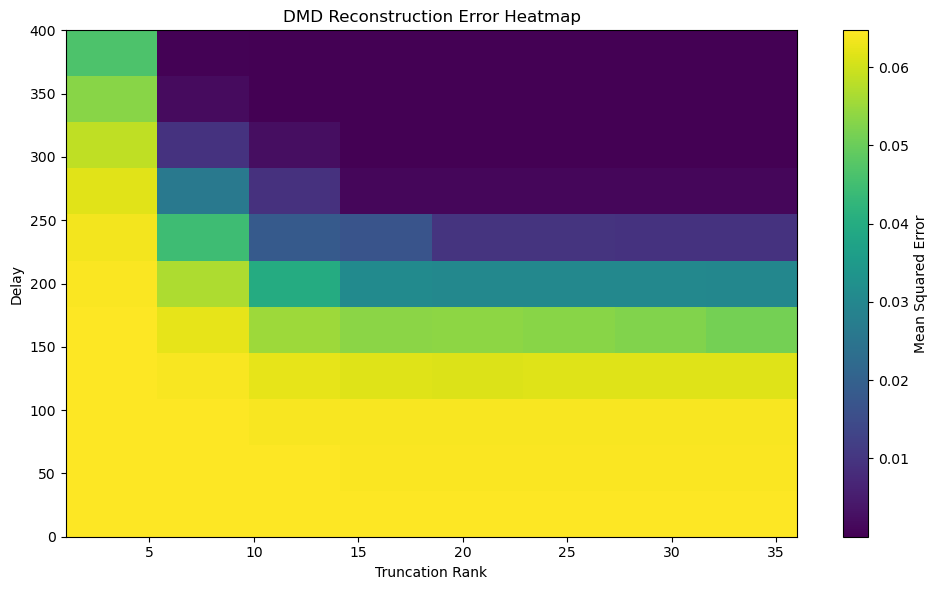

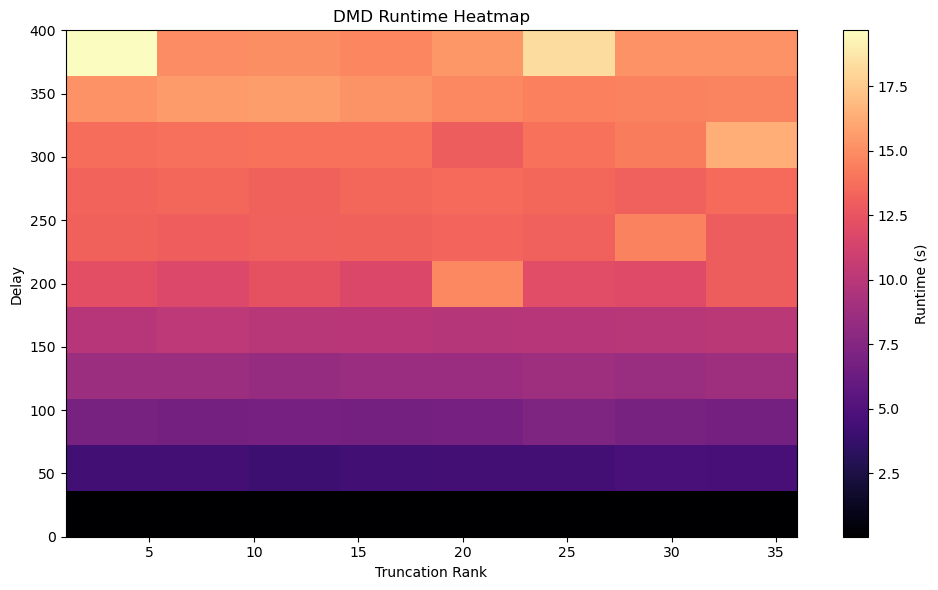

In [58]:
# ====== Imports ======
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import time
from pydmd import DMD
from pydmd.preprocessing import hankel_preprocessing

import Hamiltonian as Hamiltonian
import Plotting as plotting
import constants as cst


# ====== Set up the simulation ======
case = 2
FWHM  = 20. / cst.tfs
sigma = FWHM / (2.0 * np.sqrt(2 * np.log(2)))
E0 = 1.2
t = np.linspace(0, 100, 1000) / cst.tfs
efield_case1 = Hamiltonian.E(t, sigma, E0, ω=0.5 / cst.Ry, case=case)
J = 1.0 / cst.Ry
delta = 0.5 / cst.Ry
k_list = np.linspace(-np.pi, np.pi, 101)[:-1]
t_span = (t[0], t[-1])

solutions = np.zeros((len(k_list), 2, len(t)), dtype=np.complex64)
for k_i, k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5 / cst.Ry, case=case),
                    t_span, y0, t_eval=t)
    solutions[k_i, 0, :] = sol.y[2]
    solutions[k_i, 1, :] = sol.y[3]

t_dmd = t[:-1]
X = solutions[:, 0, :-1]
index = 50  # k-index to evaluate

# ====== Set up the nested sweep ======
delay_values = list(range(0, 401, 40))
rank_values = list(range(1, 41, 5))

errors_grid = np.zeros((len(delay_values), len(rank_values)))
timings_grid = np.zeros((len(delay_values), len(rank_values)))

for i, delay in enumerate(delay_values):
    for j, rank in enumerate(rank_values):
        start = time.time()

        dmd = DMD(svd_rank=rank)
        if delay > 0:
            dmd = hankel_preprocessing(dmd, d=delay)
        dmd.fit(X)

        elapsed = time.time() - start
        timings_grid[i, j] = elapsed

        X_dmd = dmd.reconstructed_data.real
        t_dmd_shifted = t_dmd[:X_dmd.shape[1]]
        x_dmd_shifted = X_dmd[index].real[:len(t_dmd_shifted)]
        original = X[index].real[:len(t_dmd_shifted)]
        mse = np.mean((original - x_dmd_shifted) ** 2)
        errors_grid[i, j] = mse

        print(f"delay={delay}, rank={rank}, error={mse:.4e}, time={elapsed:.4f} s")


# ====== Plot error heatmap ======
plt.figure(figsize=(10, 6))
plt.imshow(errors_grid, aspect='auto', origin='lower',
           extent=[min(rank_values), max(rank_values), min(delay_values), max(delay_values)],
           cmap='viridis')
plt.colorbar(label='Mean Squared Error')
plt.xlabel('Truncation Rank')
plt.ylabel('Delay')
plt.title('DMD Reconstruction Error Heatmap')
plt.tight_layout()
plt.show()

# ====== Plot runtime heatmap ======
plt.figure(figsize=(10, 6))
plt.imshow(timings_grid, aspect='auto', origin='lower',
           extent=[min(rank_values), max(rank_values), min(delay_values), max(delay_values)],
           cmap='magma')
plt.colorbar(label='Runtime (s)')
plt.xlabel('Truncation Rank')
plt.ylabel('Delay')
plt.title('DMD Runtime Heatmap')
plt.tight_layout()
plt.show()